In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

In [ ]:
dataset = pd.read_csv('ObesityDataSet_raw_and_data_sinthetic.csv')

In [ ]:
dataset.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


* Entries, Features

In [ ]:
dataset.shape

(2111, 17)

In [ ]:
dataset.dtypes

,0
Gender,object
Age,float64
Height,float64
Weight,float64
family_history_with_overweight,object
FAVC,object
FCVC,float64
NCP,float64
CAEC,object
SMOKE,object


In [ ]:
dataset.isnull().sum()

,0
Gender,0
Age,0
Height,0
Weight,0
family_history_with_overweight,0
FAVC,0
FCVC,0
NCP,0
CAEC,0
SMOKE,0


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

Unique values in the target column

In [ ]:
dataset['NObeyesdad'].value_counts()


,count
NObeyesdad,
Obesity_Type_I,351
Obesity_Type_III,324
Obesity_Type_II,297
Overweight_Level_I,290
Overweight_Level_II,290
Normal_Weight,287
Insufficient_Weight,272


<Axes: xlabel='count', ylabel='NObeyesdad'>

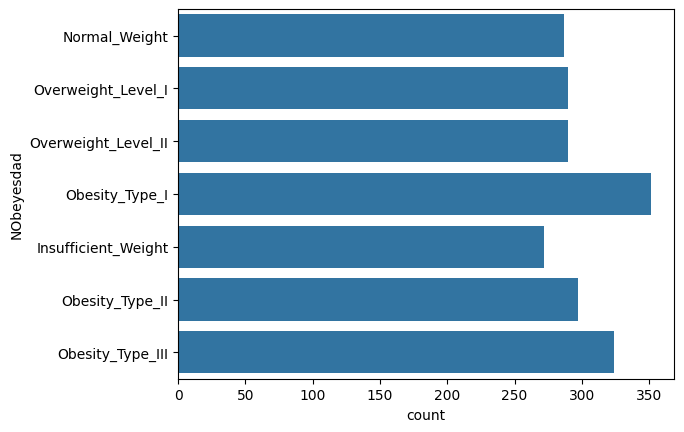

In [ ]:
sns.countplot(dataset['NObeyesdad'])

In [ ]:
dataset

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.000000,1.620000,64.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,0.000000,1.000000,no,Public_Transportation,Normal_Weight
1,Female,21.000000,1.520000,56.000000,yes,no,3.0,3.0,Sometimes,yes,3.000000,yes,3.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.000000,1.800000,77.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,2.000000,1.000000,Frequently,Public_Transportation,Normal_Weight
3,Male,27.000000,1.800000,87.000000,no,no,3.0,3.0,Sometimes,no,2.000000,no,2.000000,0.000000,Frequently,Walking,Overweight_Level_I
4,Male,22.000000,1.780000,89.800000,no,no,2.0,1.0,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III


##Imputing some data
As the data does not have any impurity, we manually impute some data so that data pre processing can be applied

In [ ]:
#numerical Values impurity

np.random.seed(42)
num_rows_to_nullify = 25
features_to_nullify = ['Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
for feature in features_to_nullify:
    random_rows = dataset.sample(n=num_rows_to_nullify).index
    dataset.loc[random_rows, feature] = np.nan


In [ ]:
#impurity for categorical data
np.random.seed(42)

num_rows_to_clear  = 10

categorical_features_to_clear = ['CALC', 'FAVC', 'SCC', 'SMOKE', 'family_history_with_overweight', 'CAEC', 'NObeyesdad']
for feature_c in categorical_features_to_clear:
    random_rows = dataset.sample(n=num_rows_to_clear).index
    dataset.loc[random_rows, feature_c] = np.nan



Making Sure of the impurification

In [ ]:
dataset.isnull().sum()

,0
Gender,0
Age,0
Height,25
Weight,25
family_history_with_overweight,10
FAVC,10
FCVC,25
NCP,25
CAEC,10
SMOKE,10


In [ ]:
dataset

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.000000,1.620000,64.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,0.000000,1.000000,no,Public_Transportation,Normal_Weight
1,Female,21.000000,1.520000,56.000000,yes,no,3.0,3.0,Sometimes,yes,3.000000,yes,3.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.000000,1.800000,77.000000,yes,no,2.0,3.0,NaN,no,2.000000,no,NaN,1.000000,Frequently,Public_Transportation,Normal_Weight
3,Male,27.000000,1.800000,87.000000,no,no,3.0,3.0,Sometimes,no,2.000000,no,2.000000,0.000000,Frequently,Walking,Overweight_Level_I
4,Male,22.000000,1.780000,89.800000,no,no,2.0,1.0,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III


##DATA PRE PROCESSING

Droping the rows where more than two values are missing as it will mislead the training

In [ ]:
print(dataset.shape)
rows_to_drop = dataset[dataset.isna().sum(axis=1) > 2].index

dataset.drop(index=rows_to_drop, inplace=True)
print("New",dataset.shape)

(2111, 17)
New (2106, 17)


In [ ]:
dataset.isnull().sum()


,0
Gender,0
Age,0
Height,25
Weight,23
family_history_with_overweight,10
FAVC,9
FCVC,23
NCP,24
CAEC,9
SMOKE,9


* Numerical columns

In [ ]:
from sklearn.impute import SimpleImputer
columns = ['Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
for item in columns:
    imputer = SimpleImputer(missing_values = np.nan, strategy='median')
    dataset[item] = imputer.fit_transform(dataset[[item]])
#dataset['Height'] = imputer.fit_transform(dataset[['Height']])


* Categorical columns

In [ ]:
from sklearn.impute import SimpleImputer

categorical_features = ['CALC', 'FAVC', 'SCC', 'SMOKE', 'family_history_with_overweight', 'CAEC', 'NObeyesdad']

imputer = SimpleImputer(strategy='most_frequent')

dataset[categorical_features] = imputer.fit_transform(dataset[categorical_features])



In [ ]:
dataset

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.000000,1.620000,64.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,0.000000,1.000000,no,Public_Transportation,Normal_Weight
1,Female,21.000000,1.520000,56.000000,yes,no,3.0,3.0,Sometimes,yes,3.000000,yes,3.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.000000,1.800000,77.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,1.000000,1.000000,Frequently,Public_Transportation,Normal_Weight
3,Male,27.000000,1.800000,87.000000,no,no,3.0,3.0,Sometimes,no,2.000000,no,2.000000,0.000000,Frequently,Walking,Overweight_Level_I
4,Male,22.000000,1.780000,89.800000,no,no,2.0,1.0,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III


In [ ]:
dataset.isnull().sum()

,0
Gender,0
Age,0
Height,0
Weight,0
family_history_with_overweight,0
FAVC,0
FCVC,0
NCP,0
CAEC,0
SMOKE,0


In [ ]:

from sklearn.preprocessing import OneHotEncoder

print(dataset.columns)
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_df = encoder.fit_transform(dataset[['CAEC']])
encoded_df = pd.DataFrame(encoded_df, columns=encoder.get_feature_names_out(['CAEC']),index = dataset.index)

print(encoded_df.index)
dataset = pd.concat([dataset, encoded_df], axis=1)

dataset = dataset.drop('CAEC', axis=1)



Index(['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight',
       'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE',
       'CALC', 'MTRANS', 'NObeyesdad'],
      dtype='object')
Index([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,
       ...
       2101, 2102, 2103, 2104, 2105, 2106, 2107, 2108, 2109, 2110],
      dtype='int64', length=2106)


In [ ]:
dataset.isnull().sum()

,0
Gender,0
Age,0
Height,0
Weight,0
family_history_with_overweight,0
FAVC,0
FCVC,0
NCP,0
SMOKE,0
CH2O,0


In [ ]:
encoder = OneHotEncoder(sparse_output= False, handle_unknown='ignore')
encoded_data = encoder.fit_transform(dataset[['MTRANS']])

encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(['MTRANS']), index=dataset.index)

dataset = pd.concat([dataset, encoded_df],axis=1)

dataset = dataset.drop('MTRANS',axis=1)

In [ ]:
dataset['CALC'].unique()
encoder = OneHotEncoder(sparse_output= False, handle_unknown='ignore')
encoded_data = encoder.fit_transform(dataset[['CALC']])

encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(['CALC']), index=dataset.index)

dataset = pd.concat([dataset, encoded_df],axis=1)

dataset = dataset.drop('CALC',axis=1)

In [ ]:
dataset['SCC'].unique()
encoder = OneHotEncoder(sparse_output= False, handle_unknown='ignore')
encoded_data = encoder.fit_transform(dataset[['SCC']])

encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(['SCC']), index=dataset.index)

dataset = pd.concat([dataset, encoded_df],axis=1)

dataset = dataset.drop('SCC',axis=1)

In [ ]:
dataset.isnull().sum()

,0
Gender,0
Age,0
Height,0
Weight,0
family_history_with_overweight,0
FAVC,0
FCVC,0
NCP,0
SMOKE,0
CH2O,0


In [ ]:
X = dataset.drop('NObeyesdad', axis=1)
y = dataset['NObeyesdad']

Certain bayes towards female as the hormonal change in female leads to a more probability to weigh more than male counterpart

In [ ]:
X['Gender'] = X['Gender'].map({'Male': 0, 'Female': 1})

Similarly to gender bayes family history with overweight also play a role in weighing more

In [ ]:
X['family_history_with_overweight'] = X['family_history_with_overweight'].map({'no': 0, 'yes': 1})

"*Even though smoking may reduce weight and smoking cessation may increase weight, smoking overall was not associated with a net weight increase as compared to never smokers. This information can alleviate concerns of weight gain in smokers who wish to quit smoking.*"
Due to very obtuse corelation to weight gain and smoking this data can mislead the training model.

Piirtola M, Jelenkovic A, Latvala A, et al. Association of current and former smoking with body mass index: A study of smoking discordant twin pairs from 21 twin cohorts. PLoS One. 2018;13(7):e0200140. Published 2018 Jul 12. doi:10.1371/journal.pone.0200140
https://pmc.ncbi.nlm.nih.gov/articles/PMC6042712/#:~:text=On%20average%2C%20current%20smokers%20have,smokers%20%5B6%E2%80%9311%5D.

In [ ]:
X = X.drop('SMOKE', axis=1)

* FAVC implies eating higher calory food. Intuitively it is a factor in gaining weight

In [ ]:
binary_columns = ['FAVC']
for column in binary_columns:
    X[column] = X[column].map({'no': 0, 'yes': 1})

In [ ]:
X.isnull().sum()

,0
Gender,0
Age,0
Height,0
Weight,0
family_history_with_overweight,0
FAVC,0
FCVC,0
NCP,0
CH2O,0
FAF,0


In [ ]:
X.shape

(2106, 26)

In [ ]:
pd.DataFrame(X)

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CH2O,FAF,...,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking,CALC_Always,CALC_Frequently,CALC_Sometimes,CALC_no,SCC_no,SCC_yes
0,1,21.000000,1.620000,64.000000,1,0,2.0,3.0,2.000000,0.000000,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
1,1,21.000000,1.520000,56.000000,1,0,3.0,3.0,3.000000,3.000000,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,0,23.000000,1.800000,77.000000,1,0,2.0,3.0,2.000000,1.000000,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,0,27.000000,1.800000,87.000000,0,0,3.0,3.0,2.000000,2.000000,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
4,0,22.000000,1.780000,89.800000,0,0,2.0,1.0,2.000000,0.000000,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,1,20.976842,1.710730,131.408528,1,1,3.0,3.0,1.728139,1.676269,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2107,1,21.982942,1.748584,133.742943,1,1,3.0,3.0,2.005130,1.341390,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2108,1,22.524036,1.752206,133.689352,1,1,3.0,3.0,2.054193,1.414209,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2109,1,24.361936,1.739450,133.346641,1,1,3.0,3.0,2.852339,1.139107,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)
list(le.classes_)
print(y)
#print(dict(zip(le.classes_, range(len(le.classes_)))))
print(y.shape)

[1 1 1 ... 4 4 4]
(2106,)


#Corelation Analysis

Text(0.5, 1.0, 'Analysis of Correlations')

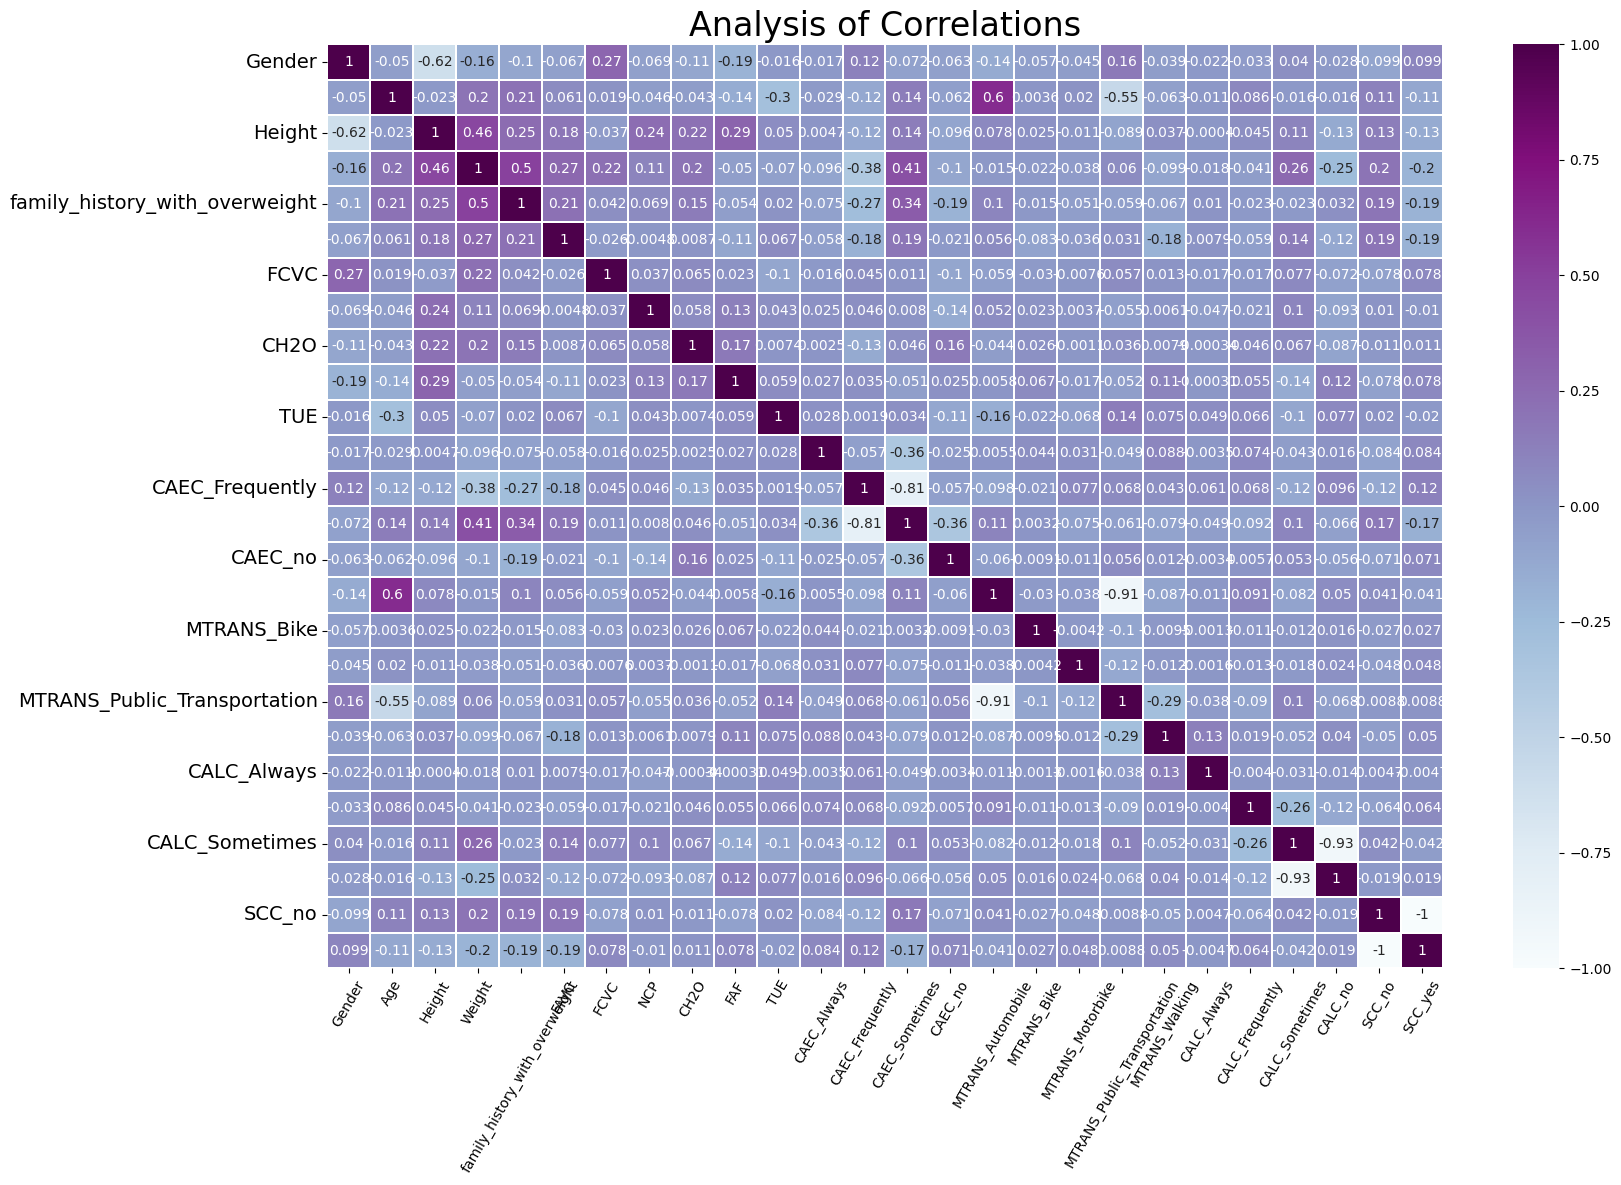

In [ ]:
sns.heatmap(X.corr(), annot = True, cmap = "BuPu", linewidths= 0.3)
fig = plt.gcf()
fig.set_size_inches(18,12)
plt.xticks(rotation = 60, size = 10)
plt.yticks(size = 14)
plt.title('Analysis of Correlations', size = 24)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1474, 26)
(632, 26)
(1474,)
(632,)


#Feature Scaling

As the feature has positively skewed, So log scaling will be a better fit

In [ ]:
from sklearn.preprocessing import RobustScaler
sc = RobustScaler()
X_train['Age'] = sc.fit_transform(X_train[['Age']])
X_test['Age'] = sc.transform(X_test[['Age']])

X_train['Weight'] = sc.fit_transform(X_train[['Weight']])
X_test['Weight'] = sc.transform(X_test[['Weight']])

In [ ]:
"""from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train['Age'] = sc.fit_transform(X_train[['Age']])
X_test['Age'] = sc.transform(X_test[['Age']])

X_train['Weight'] = sc.fit_transform(X_train[['Weight']])
X_test['Weight'] = sc.transform(X_test[['Weight']])"""

"from sklearn.preprocessing import StandardScaler\nsc = StandardScaler()\nX_train['Age'] = sc.fit_transform(X_train[['Age']])\nX_test['Age'] = sc.transform(X_test[['Age']])\n\nX_train['Weight'] = sc.fit_transform(X_train[['Weight']])\nX_test['Weight'] = sc.transform(X_test[['Weight']])"

In [ ]:
X_train

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CH2O,FAF,...,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking,CALC_Always,CALC_Frequently,CALC_Sometimes,CALC_no,SCC_no,SCC_yes
1837,1,-0.305074,1.812963,1.375246,1,1,3.000000,3.000000,2.641489,0.481555,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
572,1,-0.614223,1.768435,-0.824256,0,1,3.000000,3.725797,1.191401,2.000000,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1472,1,-0.582472,1.623377,-0.003669,1,1,1.276858,2.918124,1.403784,0.552511,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1057,0,0.278088,1.718845,0.081924,1,1,2.000000,2.677693,2.693978,0.000000,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
467,0,-0.128929,1.740000,-0.197413,1,1,3.000000,3.000000,1.000000,1.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1643,0,0.952089,1.817572,0.933168,1,1,2.969233,3.000000,2.807984,0.982134,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1099,1,-0.491523,1.653431,-0.195182,1,0,2.766036,2.443812,2.707927,0.702839,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1134,1,-0.295195,1.517998,-0.451676,1,0,2.123900,1.672958,2.000000,1.582428,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
1298,0,-0.031976,1.753081,0.302760,1,1,2.000000,3.000000,3.000000,3.000000,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0


#Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dtc = DecisionTreeClassifier(random_state=0)
dtc.fit(X_train,y_train)

DecisionTreeClassifier(random_state=0)

In [ ]:
pred = dtc.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
acc = accuracy_score(y_test,pred)
print('Accuracy Score:',acc)
print()
print("Confusion Matrix:", confusion_matrix(y_test, pred))
print()
print("Classification Report:", classification_report(y_test, pred))


Accuracy Score: 0.9145569620253164

Confusion Matrix: [[77  2  1  0  0  0  0]
 [10 73  3  0  0  6  1]
 [ 1  1 86  4  0  0  5]
 [ 0  0  2 92  0  0  1]
 [ 0  0  0  1 94  0  0]
 [ 0  7  1  0  0 74  0]
 [ 0  0  3  2  0  3 82]]

Classification Report:               precision    recall  f1-score   support

           0       0.88      0.96      0.92        80
           1       0.88      0.78      0.83        93
           2       0.90      0.89      0.89        97
           3       0.93      0.97      0.95        95
           4       1.00      0.99      0.99        95
           5       0.89      0.90      0.90        82
           6       0.92      0.91      0.92        90

    accuracy                           0.91       632
   macro avg       0.91      0.92      0.91       632
weighted avg       0.91      0.91      0.91       632



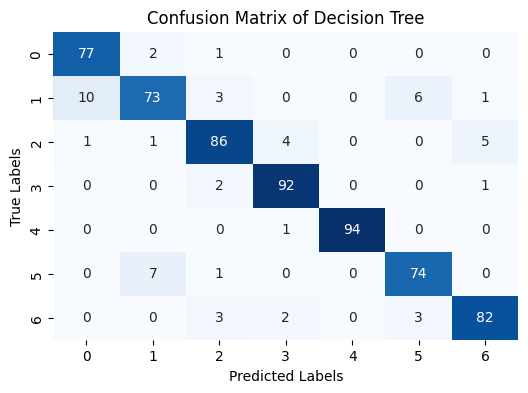

In [ ]:
dt = confusion_matrix(y_test, pred)
plt.figure(figsize=(6, 4))
sns.heatmap(dt, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix of Decision Tree')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

#Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000,random_state=0)
lr.fit(X_train,y_train)

LogisticRegression(max_iter=1000, random_state=0)

In [ ]:
pred2 = lr.predict(X_test)

In [ ]:

acc2 = accuracy_score(y_test,pred2)
print('Accuracy Score:\n',acc2)
print()
print("Confusion Matrix:\n", confusion_matrix(y_test, pred2))
print()
print("Classification Report:\n", classification_report(y_test, pred2))

Accuracy Score:
 0.7737341772151899

Confusion Matrix:
 [[74  5  0  0  0  1  0]
 [22 45  0  0  0 21  5]
 [ 2  0 79  7  1  2  6]
 [ 0  0  4 90  0  0  1]
 [ 0  0  0  1 94  0  0]
 [ 0  7  3  0  0 55 17]
 [ 0  2 24  2  0 10 52]]

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.93      0.83        80
           1       0.76      0.48      0.59        93
           2       0.72      0.81      0.76        97
           3       0.90      0.95      0.92        95
           4       0.99      0.99      0.99        95
           5       0.62      0.67      0.64        82
           6       0.64      0.58      0.61        90

    accuracy                           0.77       632
   macro avg       0.77      0.77      0.76       632
weighted avg       0.77      0.77      0.77       632



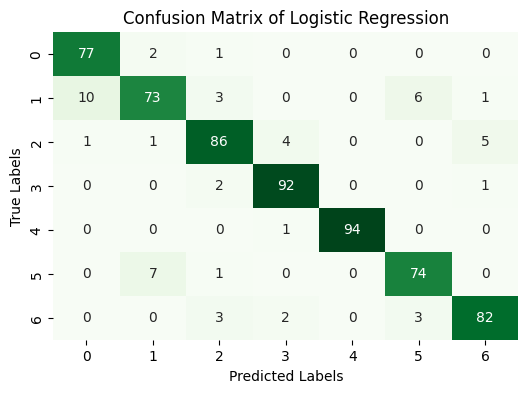

In [ ]:
lrm = confusion_matrix(y_test, pred)
plt.figure(figsize=(6, 4))
sns.heatmap(lrm, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('Confusion Matrix of Logistic Regression')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

#KNeighbors

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=45)
knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=45)

In [ ]:
pred3 = knn.predict(X_test)

In [ ]:

acc3 = accuracy_score(y_test,pred3)
print('Accuracy Score:\n',acc3)
print()
print("Confusion Matrix:\n", confusion_matrix(y_test, pred3))
print()
print("Classification Report:\n", classification_report(y_test, pred3))

Accuracy Score:
 0.6582278481012658

Confusion Matrix:
 [[70  0  2  0  1  7  0]
 [43  5 13  3  0 20  9]
 [ 4  0 76 14  1  1  1]
 [ 0  0  3 92  0  0  0]
 [ 0  0  0  0 95  0  0]
 [ 3  1 28  5  1 39  5]
 [ 0  1 31  8  4  7 39]]

Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.88      0.70        80
           1       0.71      0.05      0.10        93
           2       0.50      0.78      0.61        97
           3       0.75      0.97      0.85        95
           4       0.93      1.00      0.96        95
           5       0.53      0.48      0.50        82
           6       0.72      0.43      0.54        90

    accuracy                           0.66       632
   macro avg       0.68      0.66      0.61       632
weighted avg       0.68      0.66      0.61       632



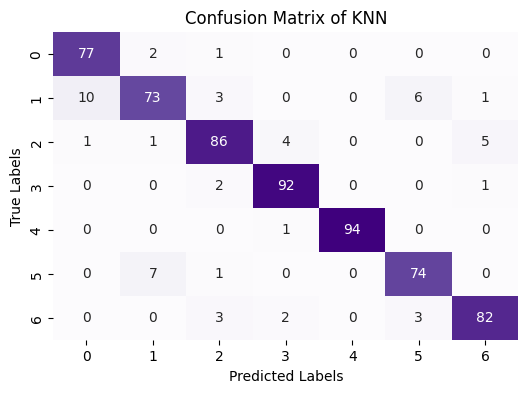

In [ ]:
knnc = confusion_matrix(y_test, pred)
plt.figure(figsize=(6, 4))
sns.heatmap(knnc, annot=True, fmt='d', cmap='Purples', cbar=False)
plt.title('Confusion Matrix of KNN')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

##Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=150, random_state=0)

rf.fit(X_train, y_train)


RandomForestClassifier(n_estimators=150, random_state=0)

In [ ]:
pred4 = rf.predict(X_test)

In [ ]:
acc4 = accuracy_score(y_test, pred4)
print('Accuracy Score:\n',acc4)
print()
print("Confusion Matrix:\n", confusion_matrix(y_test, pred4))
print()
print("Classification Report:\n", classification_report(y_test, pred4))

Accuracy Score:
 0.930379746835443

Confusion Matrix:
 [[74  6  0  0  0  0  0]
 [ 4 86  0  0  0  3  0]
 [ 1  2 90  1  0  0  3]
 [ 0  0  0 94  0  0  1]
 [ 0  1  0  0 94  0  0]
 [ 0 10  0  0  0 71  1]
 [ 0  4  3  0  0  4 79]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.93      0.93        80
           1       0.79      0.92      0.85        93
           2       0.97      0.93      0.95        97
           3       0.99      0.99      0.99        95
           4       1.00      0.99      0.99        95
           5       0.91      0.87      0.89        82
           6       0.94      0.88      0.91        90

    accuracy                           0.93       632
   macro avg       0.93      0.93      0.93       632
weighted avg       0.93      0.93      0.93       632



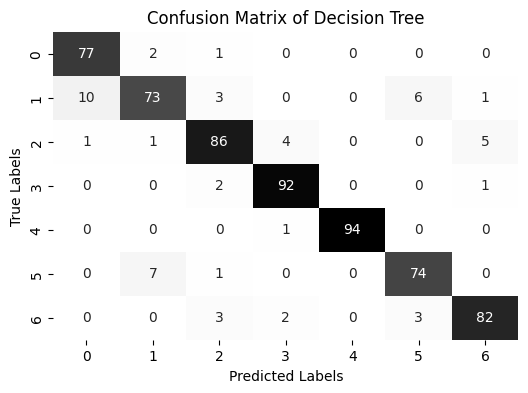

In [ ]:
rfc = confusion_matrix(y_test, pred)
plt.figure(figsize=(6, 4))
sns.heatmap(rfc, annot=True, fmt='d', cmap='Greys', cbar=False)
plt.title('Confusion Matrix of Decision Tree')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Naive Bayes


In [ ]:
from sklearn.naive_bayes import GaussianNB
GaussianClassifier = GaussianNB()
GaussianClassifier.fit(X_train, y_train)

GaussianNB()

In [ ]:
pred5 = GaussianClassifier.predict(X_test)

In [ ]:
acc5 = accuracy_score(y_test, pred5)
print('Accuracy Score:\n',acc5)
print()
print("Confusion Matrix:\n", confusion_matrix(y_test, pred5))
print()
print("Classification Report:\n", classification_report(y_test, pred5))

Accuracy Score:
 0.5126582278481012

Confusion Matrix:
 [[65  4  0 10  0  1  0]
 [54 15  5  4  0  8  7]
 [ 2  2 35 51  1  1  5]
 [ 0  0  0 94  0  1  0]
 [ 0  0  1  0 94  0  0]
 [16  6 19 23  0 10  8]
 [15  0 23 39  0  2 11]]

Classification Report:
               precision    recall  f1-score   support

           0       0.43      0.81      0.56        80
           1       0.56      0.16      0.25        93
           2       0.42      0.36      0.39        97
           3       0.43      0.99      0.59        95
           4       0.99      0.99      0.99        95
           5       0.43      0.12      0.19        82
           6       0.35      0.12      0.18        90

    accuracy                           0.51       632
   macro avg       0.52      0.51      0.45       632
weighted avg       0.52      0.51      0.46       632



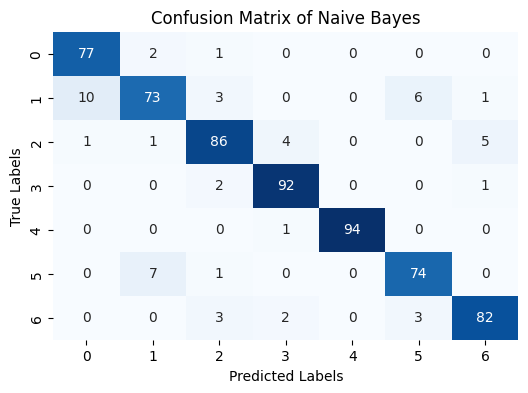

In [ ]:
gc = confusion_matrix(y_test, pred5)
plt.figure(figsize=(6, 4))
sns.heatmap(rfc, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix of Naive Bayes')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

## Prediction Accuracy chart of the Models

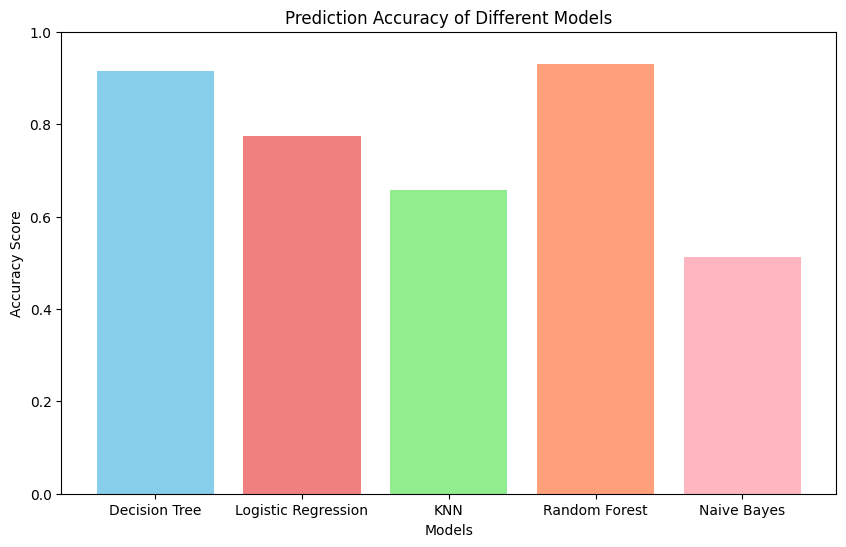

In [ ]:
models = ['Decision Tree', 'Logistic Regression', 'KNN', 'Random Forest', 'Naive Bayes']
accuracy_scores = [acc,acc2,acc3,acc4,acc5]

plt.figure(figsize=(10, 6))
plt.bar(models, accuracy_scores, color=['skyblue', 'lightcoral', 'lightgreen', 'lightsalmon', 'lightpink'])
plt.xlabel("Models")
plt.ylabel("Accuracy Score")
plt.title("Prediction Accuracy of Different Models")
plt.ylim(0, 1)
plt.show()

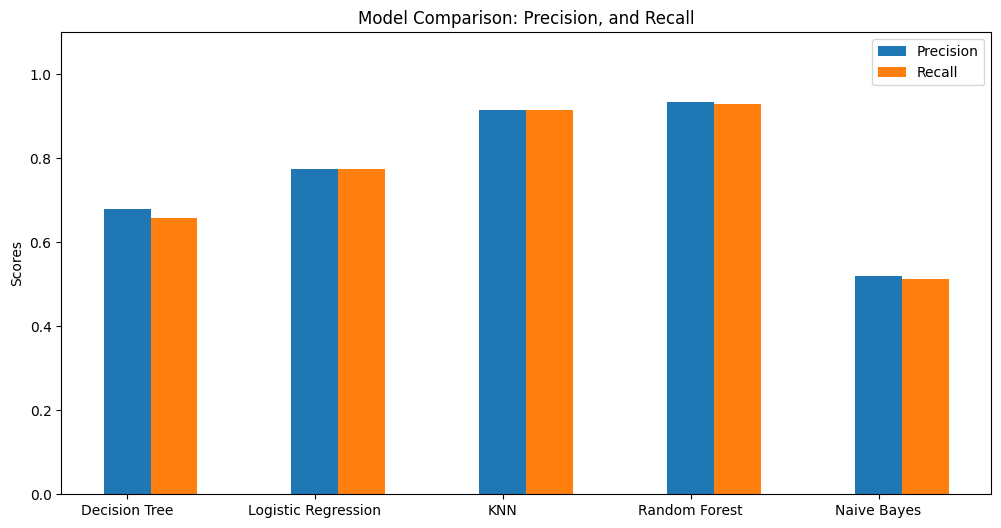

In [ ]:
from sklearn.metrics import  confusion_matrix, precision_score, recall_score
precision_dt = precision_score(y_test, pred, average='weighted')
recall_dt = recall_score(y_test, pred, average='weighted')

precision_lr = precision_score(y_test, pred2, average='weighted')
recall_lr = recall_score(y_test, pred2, average='weighted')

precision_knn = precision_score(y_test, pred3, average='weighted')
recall_knn = recall_score(y_test, pred3, average='weighted')


precision_rf = precision_score(y_test, pred4, average='weighted')
recall_rf = recall_score(y_test, pred4, average='weighted')

precision_nb = precision_score(y_test, pred5, average='weighted')
recall_nb = recall_score(y_test, pred5, average='weighted')

models = ['Decision Tree', 'Logistic Regression', 'KNN', 'Random Forest', 'Naive Bayes']
precision_scores = [precision_knn, precision_lr, precision_dt, precision_rf, precision_nb]
recall_scores = [recall_knn, recall_lr, recall_dt, recall_rf, recall_nb]


x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x, precision_scores, width, label='Precision')
rects2 = ax.bar(x + width, recall_scores, width, label='Recall')

ax.set_ylabel('Scores')
ax.set_title('Model Comparison: Precision, and Recall')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

plt.ylim(0, 1.1)

plt.show()

## Random Forest yields the highes Accuracy Score of 0.93 and an f1 score of 0.93. So, the best model for classifying this dataset is Random Forest